I'll be using this to mess around with different concepts/ideas.

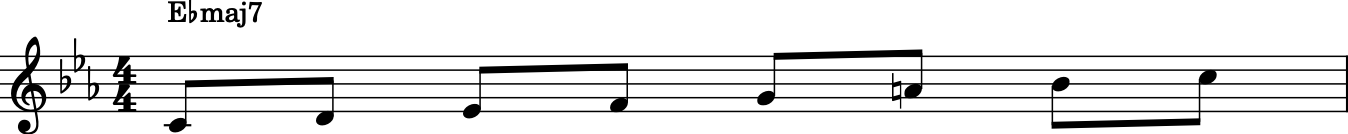

In [ ]:
from IPython.display import Image
from music21 import chord, harmony, key, metadata, meter, note, scale, stream

KEYS_MAP: dict[str, int] = {
    "C": 0,
    "Am": 0,
    "G": 1,
    "Em": 1,
    "D": 2,
    "Bm": 2,
    "A": 3,
    "F#m": 3,
    "E": 4,
    "C#m": 4,
    "B": 5,
    "G#m": 5,
    "F#": 6,
    "D#m": 6,
    "C#": 7,
    "A#m": 7,
    "F": -1,
    "Dm": -1,
    "Bb": -2,
    "Gm": -2,
    "Eb": -3,
    "Cm": -3,
    "Ab": -4,
    "Fm": -4,
    "Db": -5,
    "Bbm": -5,
    "Gb": -6,
    "Ebm": -6,
    "Cb": -7,
    "Abm": -7,
}

TIME_SIGNATURES: list[str] = [
    "2/4",
    "3/4",
    "4/4",
    "5/4",
    "6/4",
    "3/8",
    "4/8",
    "5/8",
    "6/8",
    "7/8",
    "9/8",
    "12/8",
    "2/2",
    "3/2",
]

song_key_str: str = "Eb"
song_sig_str: str = "4/4"

song_key: key.KeySignature = key.KeySignature(KEYS_MAP[song_key_str])
song_sig: meter.TimeSignature = meter.TimeSignature(song_sig_str)

song: stream.Score = stream.Score()
part: stream.Part = stream.Part()
meta: metadata.Metadata = metadata.Metadata()

measure: stream.Measure = stream.Measure()
measure.append(song_key)
measure.append(song_sig)

first_chord: harmony.ChordSymbol = harmony.ChordSymbol("E-maj7")
measure.append(first_chord)

dorian_scale: scale.DorianScale = scale.DorianScale(
    song_key.asKey().relative.tonicPitchNameWithCase
)
for n in dorian_scale.getChord():
    n.quarterLength = 0.5
    measure.append(n)

part.append(measure)
song.append(part)

Image(filename=song.write("musicxml.png"))

In [13]:
song.show("midi")

In [ ]:
from music21 import *
from fractions import Fraction

s = stream.Score()
p = stream.Part()

m = stream.Measure()

for n in ["C3", "E3", "G3", "B3", "C4", "E4", "G4", "B4"]:
    _n = note.Note(n, quarterLength=0.5)
    m.append(_n)

p.append(m)
s.append(p)


def swingify(original_stream: stream.Score, swing_ratio=2):
    long_dur = Fraction(swing_ratio, swing_ratio + 1)
    short_dur = Fraction(1, swing_ratio + 1)

    for n in original_stream.recurse().notes:
        if n.quarterLength == 0.5:
            beat_pos = n.offset % 1.0

            if beat_pos == 0.0:
                n.quarterLength = long_dur
            elif beat_pos == 0.5:
                n.offset = float(int(n.offset)) + long_dur
                n.quarterLength = short_dur

    return original_stream


swung_s = swingify(s)

s.show("midi")

Let's see how to incorporate pydantic models.

In [36]:
from enum import Enum
from fractions import Fraction
from typing import Any
from music21 import chord, harmony, key, metadata, meter, note, scale, stream
from pydantic import BaseModel, computed_field, ConfigDict, Field


class AcceptableKeys(Enum):
    C_MAJOR = "C"
    A_MINOR = "Am"
    G_MAJOR = "G"
    E_MINOR = "Em"
    D_MAJOR = "D"
    B_MINOR = "Bm"
    A_MAJOR = "A"
    FS_MINOR = "F#m"
    E_MAJOR = "E"
    CS_MINOR = "C#m"
    B_MAJOR = "B"
    GS_MINOR = "G#m"
    FS_MAJOR = "F#"
    DS_MINOR = "D#m"
    CS_MAJOR = "C#"
    AS_MINOR = "A#m"
    F_MAJOR = "F"
    D_MINOR = "Dm"
    BF_MAJOR = "Bb"
    G_MINOR = "Gm"
    EF_MAJOR = "Eb"
    C_MINOR = "Cm"
    AF_MAJOR = "Ab"
    F_MINOR = "Fm"
    DF_MAJOR = "Db"
    BF_MINOR = "Bbm"
    GF_MAJOR = "Gb"
    EF_MINOR = "Ebm"
    CF_MAJOR = "Cb"
    AF_MINOR = "Abm"


class AcceptableTimeSigs(Enum):
    TWO_FOUR = "2/4"
    THREE_FOUR = "3/4"
    FOUR_FOUR = "4/4"
    FIVE_FOUR = "5/4"
    SIX_FOUR = "6/4"
    THREE_EIGHT = "3/8"
    FOUR_EIGHT = "4/8"
    FIVE_EIGHT = "5/8"
    SIX_EIGHT = "6/8"
    SEVEN_EIGHT = "7/8"
    NINE_EIGHT = "9/8"
    TWELVE_EIGHT = "12/8"
    TWO_TWO = "2/2"
    THREE_TWO = "3/2"


class BaseSong(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    KEYS_MAP: dict[str, int] = {
        "C": 0,
        "Am": 0,
        "G": 1,
        "Em": 1,
        "D": 2,
        "Bm": 2,
        "A": 3,
        "F#m": 3,
        "E": 4,
        "C#m": 4,
        "B": 5,
        "G#m": 5,
        "F#": 6,
        "D#m": 6,
        "C#": 7,
        "A#m": 7,
        "F": -1,
        "Dm": -1,
        "Bb": -2,
        "Gm": -2,
        "Eb": -3,
        "Cm": -3,
        "Ab": -4,
        "Fm": -4,
        "Db": -5,
        "Bbm": -5,
        "Gb": -6,
        "Ebm": -6,
        "Cb": -7,
        "Abm": -7,
    }

    song_key_str: AcceptableKeys = Field(default_factory=lambda: AcceptableKeys.C_MAJOR)
    song_sig_str: AcceptableTimeSigs = Field(
        default_factory=lambda: AcceptableTimeSigs.FOUR_FOUR
    )

    song_key: key.KeySignature = key.KeySignature(0)
    song_sig: meter.TimeSignature = meter.TimeSignature("4/4")

    song: stream.Score = Field(default_factory=lambda: stream.Score())
    part: stream.Part = Field(default_factory=lambda: stream.Part())

    chords: dict[int, list[harmony.ChordSymbol]] = Field(
        default_factory=lambda: {
            0: [harmony.ChordSymbol("Dm7")],
            1: [harmony.ChordSymbol("G13")],
            2: [harmony.ChordSymbol("Cmaj7")],
            3: [harmony.ChordSymbol("A7")],
        }
    )
    
    def model_post_init(self, context: Any) -> None:
        measures: list[stream.Measure] = []

        for idx, ch in self.chords.items():
            m = stream.Measure()
            if idx == 0:
                m.append(self.song_key)
                m.append(self.song_sig)
            for c in ch:
                m.append(c)
            m.append(note.Note("C4", quarterLength=4))
            measures.append(m)
        
        for m in measures:
            self.part.append(m)
        
        self.song.append(self.part)
    
    def swingify(self, original_stream: stream.Score, swing_ratio=2) -> stream.Score:
        long_dur = Fraction(swing_ratio, swing_ratio + 1)
        short_dur = Fraction(1, swing_ratio + 1)

        for n in original_stream.recurse().notes:
            if n.quarterLength == 0.5:
                beat_pos = n.offset % 1.0

                if beat_pos == 0.0:
                    n.quarterLength = long_dur
                elif beat_pos == 0.5:
                    n.offset = float(int(n.offset)) + long_dur
                    n.quarterLength = short_dur
        
        return original_stream
    
    def show(self) -> None:
        self.song.show("musicxml.png")
    
    def play(self, swing: bool = True) -> None:
        swung_song: stream.Score = self.swingify(self.song)
        swung_song.show("midi")

In [37]:
test = BaseSong()
test.show()
test.play()